## Dataset and DataLoader

In [2]:
import torch
import torchvision
from torchvision.transforms import v2

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Create datasets for training & validation, download if necessary
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print(f'Training set has {len(training_set)} instances')
print(f'Validation set has {len(validation_set)} instances')

Training set has 60000 instances
Validation set has 10000 instances


Sandal  Coat  Sneaker  Sneaker


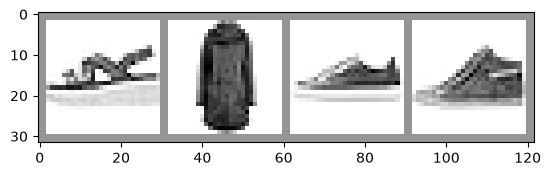

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

## The Model

In [7]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

## Loss Function

In [10]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print(f'Total loss for this batch: {loss.item()}')

tensor([[0.6571, 0.3150, 0.2281, 0.5979, 0.2950, 0.9503, 0.6049, 0.6785, 0.0139,
         0.5522],
        [0.5488, 0.1563, 0.2812, 0.8831, 0.3398, 0.9893, 0.4516, 0.0882, 0.5890,
         0.6011],
        [0.1971, 0.0509, 0.7269, 0.1542, 0.3220, 0.9730, 0.1826, 0.4235, 0.3012,
         0.6755],
        [0.8905, 0.6254, 0.4157, 0.3222, 0.5396, 0.3513, 0.9147, 0.2664, 0.8181,
         0.6443]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.3969290256500244


## Optimizer

In [13]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

## The Training Loop

In [16]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

## Per-Epoch Activity

In [19]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'model_{timestamp}_{epoch_number}'
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.8011222406849265
  batch 2000 loss: 0.8680516788028181
  batch 3000 loss: 0.6918412377797067
  batch 4000 loss: 0.6459067730428651
  batch 5000 loss: 0.603092435119208
  batch 6000 loss: 0.5412444946188479
  batch 7000 loss: 0.5057213649130426
  batch 8000 loss: 0.4927297364969854
  batch 9000 loss: 0.4836990522155538
  batch 10000 loss: 0.44135661551269006
  batch 11000 loss: 0.4412223260797327
  batch 12000 loss: 0.4222232305497164
  batch 13000 loss: 0.4297620583024109
  batch 14000 loss: 0.40080568224645685
  batch 15000 loss: 0.3948539568066772
LOSS train 0.3948539568066772 valid 0.4404968321323395
EPOCH 2:
  batch 1000 loss: 0.3759406708890892
  batch 2000 loss: 0.39474155793721727
  batch 3000 loss: 0.3758177000635769
  batch 4000 loss: 0.37085425142024175
  batch 5000 loss: 0.3738222962305008
  batch 6000 loss: 0.37660552090746935
  batch 7000 loss: 0.3712692972384393
  batch 8000 loss: 0.3453357970830257
  batch 9000 loss: 0.3626222256125184
  bat

In [20]:
saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(PATH))

NameError: name 'PATH' is not defined